# Supabase Pipeline Table Analysis

This notebook extends the older benchmark-only analysis and profiles the main Supabase tables used by the dataset-generation and recommendation pipeline.

**Primary tables covered**
- `benchmark_results`
- `prompt_logs`
- `prompt_embeddings`
- `pairwise_results`
- `model_win_rates`
- `routing_log`

**What this notebook helps answer**
- How much data exists in each pipeline table?
- Are prompt hashes, embeddings, and benchmark rows aligned?
- Are pairwise rows getting created as expected for prompt groups?
- Which models have the strongest win rates by use case and complexity?
- What does recommendation traffic in `routing_log` look like?


In [69]:
import os
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from supabase import create_client

warnings.filterwarnings('ignore')

env_path = Path('../backend/.env')
load_dotenv(env_path)

SUPABASE_URL = os.getenv('SUPABASE_URL')
SUPABASE_KEY = os.getenv('SUPABASE_KEY')
assert SUPABASE_URL and SUPABASE_KEY, 'SUPABASE_URL / SUPABASE_KEY not found in backend/.env'

sb = create_client(SUPABASE_URL, SUPABASE_KEY)

plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor': '#151a28',
    'axes.edgecolor': '#30384d',
    'axes.labelcolor': '#e5e7eb',
    'xtick.color': '#cbd5e1',
    'ytick.color': '#cbd5e1',
    'text.color': '#e5e7eb',
    'grid.color': '#334155',
    'grid.alpha': 0.35,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
})

sns.set_theme(style='darkgrid', palette='crest')

PALETTE = ['#60a5fa', '#34d399', '#fbbf24', '#f87171', '#a78bfa', '#22d3ee', '#fb7185']

print('Setup complete')

Setup complete


In [70]:
def fetch_all(table_name, columns='*', page_size=1000, order_by=None):
    rows = []
    start = 0
    while True:
        query = sb.table(table_name).select(columns)
        if order_by:
            query = query.order(order_by)
        batch = query.range(start, start + page_size - 1).execute().data or []
        rows.extend(batch)
        if len(batch) < page_size:
            break
        start += page_size
    return rows


def count_rows(table_name):
    return sb.table(table_name).select('id', count='exact').execute().count


def to_frame(rows):
    df = pd.DataFrame(rows)
    return df if not df.empty else pd.DataFrame()


def display_section(title):
    print('\n' + '=' * 100)
    print(title)
    print('=' * 100)


In [71]:
TABLES = {
    'benchmark_results': 'id,created_at,provider,model_id,use_case,prompt,prompt_complexity,response,accuracy_score,avg_accuracy_score,cost,tokens,latency_ms,clarity,eval_count,eval_conflict_flag,high_conflict_flag,low_confidence,confidence_level,prompt_hash,syntax_pass,syntax_checked,consistency_score,win_rate,is_correct,invalid,domain,has_ref_answer,prompt_version',
    'prompt_logs': '*',
    'prompt_embeddings': 'id,prompt_hash,model_name,created_at,embedding',
    'pairwise_results': 'id,created_at,prompt_hash,use_case,complexity,model_a,model_b,winner,winner_model,loser_model,judge_model,reason',
    'model_win_rates': '*',
    'routing_log': '*',
}

frames = {}
row_counts = {}

for table_name, columns in TABLES.items():
    print(f'Fetching {table_name} ...')
    rows = fetch_all(table_name, columns=columns)
    frames[table_name] = to_frame(rows)
    row_counts[table_name] = len(rows)

count_df = pd.DataFrame(
    [{'table': name, 'rows_loaded': count} for name, count in row_counts.items()]
).sort_values('rows_loaded', ascending=False)

count_df

Fetching benchmark_results ...
Fetching prompt_logs ...
Fetching prompt_embeddings ...
Fetching pairwise_results ...
Fetching model_win_rates ...
Fetching routing_log ...


,table,rows_loaded
0,benchmark_results,8607
3,pairwise_results,5632
1,prompt_logs,634
2,prompt_embeddings,557
4,model_win_rates,176
5,routing_log,21


## 1. Table Inventory And Column Snapshot

In [72]:
inventory_rows = []
for name, df in frames.items():
    inventory_rows.append({
        'table': name,
        'rows': len(df),
        'columns': len(df.columns),
        'sample_columns': ', '.join(list(df.columns[:8]))
    })

inventory_df = pd.DataFrame(inventory_rows).sort_values(['rows', 'columns'], ascending=False)
inventory_df

,table,rows,columns,sample_columns
0,benchmark_results,8607,29,"id, created_at, provider, model_id, use_case, ..."
3,pairwise_results,5632,12,"id, created_at, prompt_hash, use_case, complex..."
1,prompt_logs,634,5,"id, prompt, use_case, clarity, created_at"
2,prompt_embeddings,557,5,"id, prompt_hash, model_name, created_at, embed..."
4,model_win_rates,176,14,"model_id, use_case, complexity, win_rate, tota..."
5,routing_log,21,13,"id, request_id, prompt_hash, use_case, complex..."


In [73]:
for name, df in frames.items():
    display_section(f'{name} | shape={df.shape}')
    print(df.dtypes.astype(str).to_string())
    display(df.head(3))


benchmark_results | shape=(8607, 29)
id                     object
created_at             object
provider               object
model_id               object
use_case               object
prompt                 object
prompt_complexity      object
response               object
accuracy_score        float64
avg_accuracy_score    float64
cost                  float64
tokens                  int64
latency_ms              int64
clarity                object
eval_count            float64
eval_conflict_flag       bool
high_conflict_flag       bool
low_confidence           bool
confidence_level      float64
prompt_hash            object
syntax_pass            object
syntax_checked           bool
consistency_score      object
win_rate               object
is_correct             object
invalid                  bool
domain                 object
has_ref_answer           bool
prompt_version          int64


,id,created_at,provider,model_id,use_case,prompt,prompt_complexity,response,accuracy_score,avg_accuracy_score,...,prompt_hash,syntax_pass,syntax_checked,consistency_score,win_rate,is_correct,invalid,domain,has_ref_answer,prompt_version
0,2cc4c15a-2e41-4a68-aa1f-8e02760feac4,2026-03-26T18:43:58.319678+00:00,Amazon,nova-pro,reasoning,"In a city, 60% of residents prefer public tran...",mid,To find the probability that exactly 3 out of ...,100.0,95.00,...,bbe9f78b055b2b5aa3cbefb00a14e025,None,False,None,None,None,False,None,False,1
1,a9ccc879-21cd-49a6-a188-6d50e0762925,2026-03-25T17:13:33.994263+00:00,Meta,llama4-maverick,text-generation,Create a brief message inviting a friend to yo...,low,"Here's a brief invitation message:\n\n""Hey! I'...",95.0,97.67,...,7f34e02e9f6159e0d8eba37273b48040,None,False,None,None,None,False,None,False,1
2,fec4d235-4fe3-46ee-8dc4-8572ad552f69,2026-03-26T17:50:23.475811+00:00,Google,gemini-3-1-pro,code-generation,Write a JavaScript class that implements a sim...,mid,"Here is a clean, modern JavaScript implementat...",92.0,95.00,...,02529ca367ce247fcdc2b73708417f15,None,False,None,None,None,False,None,False,1



prompt_logs | shape=(634, 5)
id             int64
prompt        object
use_case      object
clarity       object
created_at    object


,id,prompt,use_case,clarity,created_at
0,21,Find two indices whose sum equals target using...,code-generation,CLEAR,2026-03-25T17:12:12.338078+00:00
1,22,Best time to buy and sell stock for maximum pr...,code-generation,CLEAR,2026-03-25T17:12:12.64612+00:00
2,23,Check if a string is a palindrome ignoring non...,code-generation,CLEAR,2026-03-25T17:12:12.941696+00:00



prompt_embeddings | shape=(557, 5)
id             object
prompt_hash    object
model_name     object
created_at     object
embedding      object


...

,id,created_at,prompt_hash,use_case,complexity,model_a,model_b,winner,winner_model,loser_model,judge_model,reason
0,54af643c-13ca-46ea-8c4c-ebbe016a86a9,2026-04-16T13:01:49.583721+00:00,bbe9f78b055b2b5aa3cbefb00a14e025,reasoning,mid,nova-lite,pixtral-large-2,A,nova-lite,pixtral-large-2,"llama4-maverick,mistral-large",llama4-maverick: Response A provides a more de...
1,2b73e658-dbe1-42d8-86c0-dec2979eab24,2026-04-16T13:31:15.245002+00:00,c6b20a5fb41e4af1ddbf8fc3750600e3,text-generation,mid,gemini-2-5-pro,llama4-maverick,A,gemini-2-5-pro,llama4-maverick,"llama4-maverick,mistral-large,nova-premier",llama4-maverick: Response A provides a more co...
2,10542635-94f9-49dc-8972-153b76f32ca6,2026-04-16T13:01:51.340463+00:00,bbe9f78b055b2b5aa3cbefb00a14e025,reasoning,mid,nova-lite,gemini-2-5-flash,B,gemini-2-5-flash,nova-lite,"llama4-maverick,mistral-large",llama4-maverick: Both responses are accurate a...



model_win_rates | shape=(176, 14)
model_id                 object
use_case                 object
complexity               object
win_rate                float64
total_matches             int64
wins                      int64
losses                    int64
ties                      int64
judge_count               int64
last_updated             object
total_participations      int64
decisive_matches          int64
tie_rate                float64
confidence              float64


,model_id,use_case,complexity,win_rate,total_matches,wins,losses,ties,judge_count,last_updated,total_participations,decisive_matches,tie_rate,confidence
0,nova-lite,reasoning,mid,0.4752,101,48,53,0,3,2026-04-16T14:34:00.259278+00:00,101,101,0.0000,1.0
1,nova-lite,reasoning,all,0.4571,245,112,133,0,3,2026-04-16T14:34:00.259278+00:00,245,245,0.0000,1.0
2,pixtral-large-2,reasoning,mid,0.4795,74,35,38,1,3,2026-04-16T14:34:00.259278+00:00,74,73,0.0135,1.0



routing_log | shape=(21, 13)
id                    object
request_id            object
prompt_hash           object
use_case              object
complexity            object
clarity               object
recommended_model     object
data_source           object
knn_neighbors          int64
filter_level          object
expected_accuracy    float64
confidence           float64
created_at            object


,id,request_id,prompt_hash,use_case,complexity,clarity,recommended_model,data_source,knn_neighbors,filter_level,expected_accuracy,confidence,created_at
0,3f02c923-2b47-4224-9c5d-0dd4bb5c3a46,2d1bbf38,8e06682ae3df3c1d8b023c964ea51067,code-generation,low,PARTIAL,gemini-2-0-flash,knn,39,semantic_knn,99.38,0.942,2026-04-16T02:14:14.832762+00:00
1,b74145c4-f03e-412c-b4f3-3e31050e92a9,98018672,8e06682ae3df3c1d8b023c964ea51067,code-generation,low,PARTIAL,gemini-2-0-flash,knn,39,semantic_knn,99.38,0.942,2026-04-16T02:16:22.756567+00:00
2,637a3bd3-46f8-4f9b-86e4-ba30b1e97806,30dd2343,d3ba74b4104bd2d351586eeaa812e714,code-generation,low,CLEAR,gemini-2-0-flash,knn,39,semantic_knn,99.39,0.942,2026-04-16T04:31:01.140552+00:00


## 2. Normalize And Clean

In [74]:
benchmark_df = frames['benchmark_results'].copy()
prompt_logs_df = frames['prompt_logs'].copy()
embeddings_df = frames['prompt_embeddings'].copy()
pairwise_df = frames['pairwise_results'].copy()
win_rates_df = frames['model_win_rates'].copy()
routing_df = frames['routing_log'].copy()

if not benchmark_df.empty:
    numeric_cols = [
        'accuracy_score', 'avg_accuracy_score', 'cost', 'tokens', 'latency_ms',
        'eval_count', 'confidence_level', 'consistency_score', 'win_rate', 'prompt_version'
    ]
    for col in numeric_cols:
        if col in benchmark_df.columns:
            benchmark_df[col] = pd.to_numeric(benchmark_df[col], errors='coerce')

    bool_cols = ['eval_conflict_flag', 'high_conflict_flag', 'low_confidence', 'syntax_pass', 'syntax_checked', 'is_correct', 'invalid', 'has_ref_answer']
    for col in bool_cols:
        if col in benchmark_df.columns:
            benchmark_df[col] = benchmark_df[col].astype('boolean')

    for col in ['created_at']:
        if col in benchmark_df.columns:
            benchmark_df[col] = pd.to_datetime(benchmark_df[col], errors='coerce')

    for col in ['use_case', 'prompt_complexity', 'clarity', 'provider', 'model_id', 'domain']:
        if col in benchmark_df.columns:
            benchmark_df[col] = benchmark_df[col].astype(str).str.strip()

    benchmark_df['primary_accuracy'] = benchmark_df['avg_accuracy_score'].combine_first(benchmark_df['accuracy_score'])
    benchmark_df['has_prompt_hash'] = benchmark_df['prompt_hash'].notna() & benchmark_df['prompt_hash'].astype(str).ne('')
    benchmark_df['has_response'] = benchmark_df['response'].notna() & benchmark_df['response'].astype(str).str.strip().ne('')
    benchmark_df['latency_s'] = benchmark_df['latency_ms'] / 1000.0

if not prompt_logs_df.empty:
    if 'created_at' in prompt_logs_df.columns:
        prompt_logs_df['created_at'] = pd.to_datetime(prompt_logs_df['created_at'], errors='coerce')
    for col in ['use_case', 'clarity']:
        if col in prompt_logs_df.columns:
            prompt_logs_df[col] = prompt_logs_df[col].astype(str).str.strip()
    if 'prompt_hash' in prompt_logs_df.columns:
        prompt_logs_df['has_prompt_hash'] = prompt_logs_df['prompt_hash'].notna() & prompt_logs_df['prompt_hash'].astype(str).ne('')

if not embeddings_df.empty:
    if 'created_at' in embeddings_df.columns:
        embeddings_df['created_at'] = pd.to_datetime(embeddings_df['created_at'], errors='coerce')
    embeddings_df['embedding_present'] = embeddings_df['embedding'].notna()

if not pairwise_df.empty:
    if 'created_at' in pairwise_df.columns:
        pairwise_df['created_at'] = pd.to_datetime(pairwise_df['created_at'], errors='coerce')
    for col in ['use_case', 'complexity', 'winner', 'winner_model', 'model_a', 'model_b', 'judge_model']:
        if col in pairwise_df.columns:
            pairwise_df[col] = pairwise_df[col].astype(str).str.strip()
    pairwise_df['is_tie'] = pairwise_df['winner'].eq('TIE') | pairwise_df['winner_model'].eq('TIE')
    pairwise_df['judge_count'] = pairwise_df['judge_model'].fillna('').astype(str).apply(lambda x: len([y for y in x.split(',') if y.strip()]))

if not win_rates_df.empty:
    if 'last_updated' in win_rates_df.columns:
        win_rates_df['last_updated'] = pd.to_datetime(win_rates_df['last_updated'], errors='coerce')
    numeric_cols = ['win_rate', 'total_matches', 'wins', 'losses', 'ties', 'judge_count', 'total_participations', 'decisive_matches', 'tie_rate', 'confidence']
    for col in numeric_cols:
        if col in win_rates_df.columns:
            win_rates_df[col] = pd.to_numeric(win_rates_df[col], errors='coerce')

if not routing_df.empty:
    if 'created_at' in routing_df.columns:
        routing_df['created_at'] = pd.to_datetime(routing_df['created_at'], errors='coerce')
    numeric_cols = ['knn_neighbors', 'expected_accuracy', 'confidence']
    for col in numeric_cols:
        if col in routing_df.columns:
            routing_df[col] = pd.to_numeric(routing_df[col], errors='coerce')

print('Normalization complete')

Normalization complete


## 3. High-Level Pipeline Health

In [75]:
health = {
    'benchmark_rows': len(benchmark_df),
    'unique_benchmark_prompts': benchmark_df['prompt_hash'].nunique() if 'prompt_hash' in benchmark_df else np.nan,
    'prompt_logs_rows': len(prompt_logs_df),
    'embedding_rows': len(embeddings_df),
    'pairwise_rows': len(pairwise_df),
    'win_rate_rows': len(win_rates_df),
    'routing_rows': len(routing_df),
    'benchmark_prompt_hash_coverage_pct': round(100 * benchmark_df['has_prompt_hash'].mean(), 2) if 'has_prompt_hash' in benchmark_df else np.nan,
    'benchmark_response_coverage_pct': round(100 * benchmark_df['has_response'].mean(), 2) if 'has_response' in benchmark_df else np.nan,
    'embedding_non_null_pct': round(100 * embeddings_df['embedding_present'].mean(), 2) if 'embedding_present' in embeddings_df else np.nan,
}

pd.DataFrame([health]).T.rename(columns={0: 'value'})

,value
benchmark_rows,8607.0
unique_benchmark_prompts,552.0
prompt_logs_rows,634.0
embedding_rows,557.0
pairwise_rows,5632.0
win_rate_rows,176.0
routing_rows,21.0
benchmark_prompt_hash_coverage_pct,100.0
benchmark_response_coverage_pct,100.0
embedding_non_null_pct,100.0


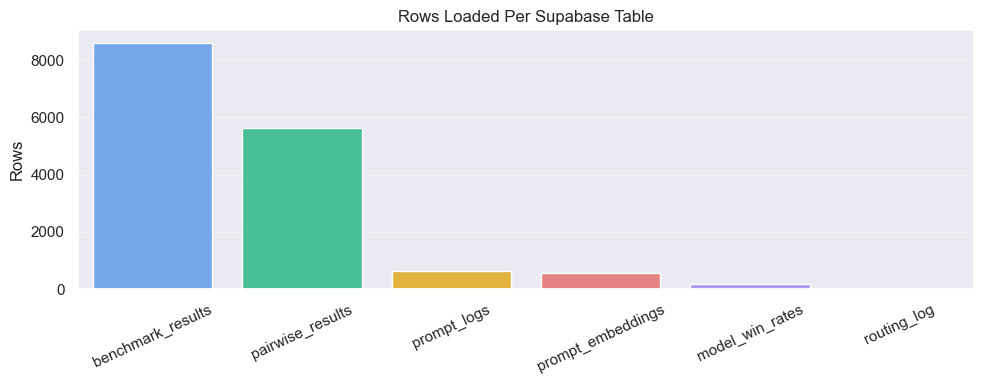

In [76]:
fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=count_df, x='table', y='rows_loaded', palette=PALETTE, ax=ax)
ax.set_title('Rows Loaded Per Supabase Table')
ax.set_xlabel('')
ax.set_ylabel('Rows')
ax.tick_params(axis='x', rotation=25)
plt.tight_layout()
plt.show()

## 4. `benchmark_results` Deep Dive

In [77]:
benchmark_summary = pd.DataFrame([
    {'metric': 'rows', 'value': len(benchmark_df)},
    {'metric': 'unique_models', 'value': benchmark_df['model_id'].nunique()},
    {'metric': 'unique_providers', 'value': benchmark_df['provider'].nunique()},
    {'metric': 'unique_use_cases', 'value': benchmark_df['use_case'].nunique()},
    {'metric': 'unique_prompt_hashes', 'value': benchmark_df['prompt_hash'].nunique()},
    {'metric': 'median_cost', 'value': benchmark_df['cost'].median()},
    {'metric': 'median_latency_ms', 'value': benchmark_df['latency_ms'].median()},
    {'metric': 'median_tokens', 'value': benchmark_df['tokens'].median()},
    {'metric': 'rows_with_primary_accuracy', 'value': benchmark_df['primary_accuracy'].notna().sum()},
])
benchmark_summary

,metric,value
0,rows,8607.000000
1,unique_models,21.000000
2,unique_providers,5.000000
3,unique_use_cases,3.000000
4,unique_prompt_hashes,552.000000
5,median_cost,0.001015
6,median_latency_ms,20102.000000
7,median_tokens,679.000000
8,rows_with_primary_accuracy,8601.000000


In [78]:
display(benchmark_df['use_case'].value_counts(dropna=False).rename_axis('use_case').reset_index(name='rows'))
display(benchmark_df['prompt_complexity'].value_counts(dropna=False).rename_axis('prompt_complexity').reset_index(name='rows'))
display(benchmark_df['clarity'].value_counts(dropna=False).rename_axis('clarity').reset_index(name='rows'))

,use_case,rows
0,text-generation,4391
1,code-generation,2139
2,reasoning,2077


,prompt_complexity,rows
0,low,3793
1,mid,2672
2,high,2142


,clarity,rows
0,CLEAR,5140
1,PARTIAL,2642
2,UNCLEAR,825


In [79]:
unique_prompt_distribution = (
    benchmark_df.dropna(subset=['prompt_hash'])
    .groupby(['use_case', 'prompt_complexity'], dropna=False)
    .agg(unique_prompts=('prompt_hash', 'nunique'))
    .reset_index()
    .sort_values(['use_case', 'prompt_complexity'])
)

display(unique_prompt_distribution)

display(
    unique_prompt_distribution.pivot_table(
        index='use_case',
        columns='prompt_complexity',
        values='unique_prompts',
        aggfunc='sum',
        fill_value=0
    )
)

display(
    benchmark_df.dropna(subset=['prompt_hash'])
    .groupby('use_case', dropna=False)
    .agg(unique_prompts=('prompt_hash', 'nunique'))
    .reset_index()
    .sort_values('unique_prompts', ascending=False)
)

display(
    benchmark_df.dropna(subset=['prompt_hash'])
    .groupby('prompt_complexity', dropna=False)
    .agg(unique_prompts=('prompt_hash', 'nunique'))
    .reset_index()
    .sort_values('unique_prompts', ascending=False)
)

,use_case,prompt_complexity,unique_prompts
0,code-generation,high,60
1,code-generation,low,50
2,code-generation,mid,56
3,reasoning,high,50
4,reasoning,low,50
5,reasoning,mid,49
6,text-generation,high,50
7,text-generation,low,116
8,text-generation,mid,76


prompt_complexity,high,low,mid
use_case,,,
code-generation,60,50,56
reasoning,50,50,49
text-generation,50,116,76


,use_case,unique_prompts
2,text-generation,242
0,code-generation,166
1,reasoning,149


,prompt_complexity,unique_prompts
1,low,216
2,mid,181
0,high,160


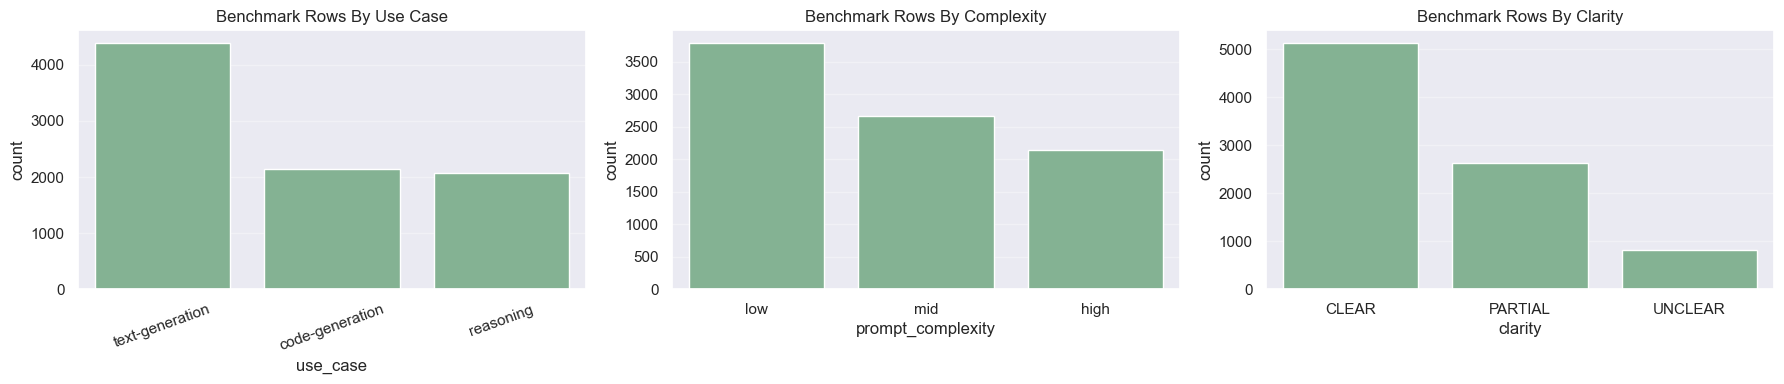

In [80]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.countplot(data=benchmark_df, x='use_case', order=benchmark_df['use_case'].value_counts().index, ax=axes[0])
axes[0].set_title('Benchmark Rows By Use Case')
axes[0].tick_params(axis='x', rotation=20)

sns.countplot(data=benchmark_df, x='prompt_complexity', order=['low', 'mid', 'high'], ax=axes[1])
axes[1].set_title('Benchmark Rows By Complexity')

sns.countplot(data=benchmark_df, x='clarity', order=benchmark_df['clarity'].value_counts().index, ax=axes[2])
axes[2].set_title('Benchmark Rows By Clarity')

plt.tight_layout()
plt.show()

In [81]:
model_rollup = (
    benchmark_df.groupby(['provider', 'model_id'], dropna=False)
    .agg(
        rows=('id', 'count'),
        prompts=('prompt_hash', 'nunique'),
        median_cost=('cost', 'median'),
        median_latency_ms=('latency_ms', 'median'),
        median_tokens=('tokens', 'median'),
        mean_primary_accuracy=('primary_accuracy', 'mean')
    )
    .reset_index()
    .sort_values(['rows', 'mean_primary_accuracy'], ascending=[False, False])
)
model_rollup.head(25)

,provider,model_id,rows,prompts,median_cost,median_latency_ms,median_tokens,mean_primary_accuracy
2,Amazon,nova-pro,620,550,0.001996,10366.5,643.0,91.776532
20,Mistral AI,pixtral-large-2,620,550,0.004350,15054.0,745.0,90.722362
1,Amazon,nova-premier,618,548,0.007791,16662.5,667.5,92.734320
18,Mistral AI,mistral-large,618,548,0.004342,16662.0,386.0,89.397104
13,Meta,llama4-maverick,617,547,0.000525,7118.0,628.0,92.530455
4,Google,gemini-2-0-flash,610,541,0.000376,18854.5,948.0,92.154492
9,Google,gemini-3-1-pro,589,521,0.008948,31286.0,914.0,93.944058
7,Google,gemini-2-5-pro,563,510,0.014745,43490.0,1509.0,93.847602
6,Google,gemini-2-5-flash,553,500,0.000758,29245.0,1274.0,93.477595
0,Amazon,nova-lite,454,389,0.000121,9445.0,546.5,91.926836


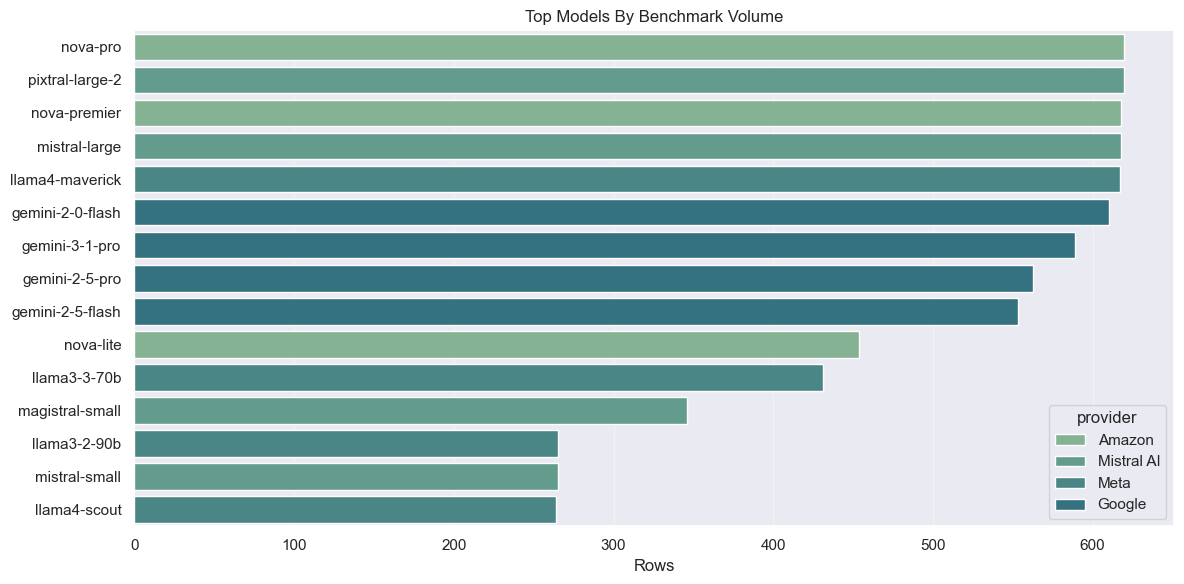

In [82]:
top_models = model_rollup.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_models, y='model_id', x='rows', hue='provider', dodge=False, ax=ax)
ax.set_title('Top Models By Benchmark Volume')
ax.set_xlabel('Rows')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [83]:
quality_checks = pd.DataFrame([
    {'check': 'missing_prompt_hash', 'rows': benchmark_df['prompt_hash'].isna().sum()},
    {'check': 'missing_response', 'rows': benchmark_df['response'].isna().sum()},
    {'check': 'missing_cost', 'rows': benchmark_df['cost'].isna().sum()},
    {'check': 'missing_latency_ms', 'rows': benchmark_df['latency_ms'].isna().sum()},
    {'check': 'invalid_true', 'rows': benchmark_df['invalid'].fillna(False).sum() if 'invalid' in benchmark_df else 0},
    {'check': 'low_confidence_true', 'rows': benchmark_df['low_confidence'].fillna(False).sum() if 'low_confidence' in benchmark_df else 0},
    {'check': 'eval_conflict_true', 'rows': benchmark_df['eval_conflict_flag'].fillna(False).sum() if 'eval_conflict_flag' in benchmark_df else 0},
    {'check': 'duplicate_model_prompt_rows', 'rows': benchmark_df.duplicated(subset=['prompt_hash', 'model_id'], keep=False).sum()},
])
quality_checks

,check,rows
0,missing_prompt_hash,0
1,missing_response,0
2,missing_cost,0
3,missing_latency_ms,0
4,invalid_true,0
5,low_confidence_true,220
6,eval_conflict_true,371
7,duplicate_model_prompt_rows,1798


## 5. `prompt_logs` Analysis

In [84]:
prompt_logs_summary = pd.DataFrame([
    {'metric': 'rows', 'value': len(prompt_logs_df)},
    {'metric': 'unique_prompts', 'value': prompt_logs_df['prompt'].nunique() if 'prompt' in prompt_logs_df else np.nan},
    {'metric': 'rows_with_prompt_hash', 'value': prompt_logs_df['has_prompt_hash'].sum() if 'has_prompt_hash' in prompt_logs_df else 0},
])
prompt_logs_summary

,metric,value
0,rows,634
1,unique_prompts,563
2,rows_with_prompt_hash,0


In [85]:
display(prompt_logs_df['use_case'].value_counts(dropna=False).rename_axis('use_case').reset_index(name='rows'))
display(prompt_logs_df['clarity'].value_counts(dropna=False).rename_axis('clarity').reset_index(name='rows'))

if 'prompt' in prompt_logs_df.columns:
    prompt_logs_df['prompt_length'] = prompt_logs_df['prompt'].astype(str).str.len()
    display(prompt_logs_df['prompt_length'].describe(percentiles=[0.5, 0.9, 0.95, 0.99]).to_frame('prompt_length'))

,use_case,rows
0,text-generation,273
1,reasoning,190
2,code-generation,171


,clarity,rows
0,CLEAR,405
1,PARTIAL,177
2,UNCLEAR,52


,prompt_length
count,634.000000
mean,138.119874
std,130.732466
min,13.000000
50%,83.000000
90%,304.000000
95%,462.100000
99%,579.000000
max,674.000000


## 6. `prompt_embeddings` Analysis

In [86]:
embedding_summary = pd.DataFrame([
    {'metric': 'rows', 'value': len(embeddings_df)},
    {'metric': 'unique_prompt_hashes', 'value': embeddings_df['prompt_hash'].nunique() if 'prompt_hash' in embeddings_df else np.nan},
    {'metric': 'non_null_embeddings', 'value': embeddings_df['embedding_present'].sum() if 'embedding_present' in embeddings_df else np.nan},
    {'metric': 'distinct_model_names', 'value': embeddings_df['model_name'].nunique() if 'model_name' in embeddings_df else np.nan},
])
embedding_summary

,metric,value
0,rows,557
1,unique_prompt_hashes,557
2,non_null_embeddings,557
3,distinct_model_names,1


In [87]:
if 'model_name' in embeddings_df.columns:
    display(embeddings_df['model_name'].value_counts(dropna=False).rename_axis('model_name').reset_index(name='rows'))

embedding_coverage = benchmark_df[['prompt_hash']].dropna().drop_duplicates().merge(
    embeddings_df[['prompt_hash', 'embedding_present']].drop_duplicates(),
    on='prompt_hash',
    how='left'
)

embedding_coverage['embedding_present'] = embedding_coverage['embedding_present'].fillna(False)
embedding_coverage['coverage_label'] = np.where(embedding_coverage['embedding_present'], 'has_embedding', 'missing_embedding')
embedding_coverage['coverage_label'].value_counts().rename_axis('coverage').reset_index(name='prompt_hashes')

,model_name,rows
0,all-MiniLM-L6-v2,557


,coverage,prompt_hashes
0,has_embedding,552


## 7. `pairwise_results` Analysis

In [88]:
pairwise_summary = pd.DataFrame([
    {'metric': 'rows', 'value': len(pairwise_df)},
    {'metric': 'unique_prompt_hashes', 'value': pairwise_df['prompt_hash'].nunique() if 'prompt_hash' in pairwise_df else np.nan},
    {'metric': 'tie_rows', 'value': pairwise_df['is_tie'].sum() if 'is_tie' in pairwise_df else np.nan},
    {'metric': 'avg_judges_per_pair', 'value': pairwise_df['judge_count'].mean() if 'judge_count' in pairwise_df else np.nan},
])
pairwise_summary

,metric,value
0,rows,5632.000000
1,unique_prompt_hashes,551.000000
2,tie_rows,50.000000
3,avg_judges_per_pair,2.942294


In [89]:
display(pairwise_df['use_case'].value_counts(dropna=False).rename_axis('use_case').reset_index(name='rows'))
display(pairwise_df['complexity'].value_counts(dropna=False).rename_axis('complexity').reset_index(name='rows'))
display(pairwise_df['winner_model'].value_counts(dropna=False).head(20).rename_axis('winner_model').reset_index(name='wins_as_selected_winner'))

,use_case,rows
0,text-generation,2454
1,code-generation,1717
2,reasoning,1461


,complexity,rows
0,low,2129
1,mid,1862
2,high,1641


,winner_model,wins_as_selected_winner
0,gemini-3-1-pro,701
1,gemini-2-5-pro,638
2,gemini-2-5-flash,601
3,gemini-2-0-flash,463
4,nova-premier,445
5,nova-pro,394
6,llama4-maverick,299
7,pixtral-large-2,283
8,nova-lite,263
9,magistral-small,234


In [90]:
pairs_by_prompt = pairwise_df.groupby('prompt_hash', dropna=False).size().rename('actual_pairs').reset_index()

benchmark_group_sizes = (
    benchmark_df[benchmark_df['has_response']]
    .groupby('prompt_hash', dropna=False)
    .agg(model_count=('model_id', 'nunique'))
    .reset_index()
)
benchmark_group_sizes['expected_pairs'] = benchmark_group_sizes['model_count'] * (benchmark_group_sizes['model_count'] - 1) / 2

pairwise_completeness = benchmark_group_sizes.merge(pairs_by_prompt, on='prompt_hash', how='left')
pairwise_completeness['actual_pairs'] = pairwise_completeness['actual_pairs'].fillna(0)
pairwise_completeness['pairwise_gap'] = pairwise_completeness['expected_pairs'] - pairwise_completeness['actual_pairs']

pairwise_completeness.sort_values(['pairwise_gap', 'expected_pairs'], ascending=[False, False]).head(20)

,prompt_hash,model_count,expected_pairs,actual_pairs,pairwise_gap
323,9685c092496e3b02f5118b21ab13978c,20,190.0,7.0,183.0
367,a72fdf34bb5223620de200b8733fc58f,20,190.0,10.0,180.0
117,31cb01883a164281a5347e9afb7947e3,19,171.0,9.0,162.0
102,29f41d47604518868a435e82d80fd65e,18,153.0,10.0,143.0
41,11fc06c11af0ff62c093ddca3b92cc57,17,136.0,5.0,131.0
499,e80e2379ff25d444755f64275707d939,17,136.0,5.0,131.0
61,1c464565bf5d5769b426f012d9350552,17,136.0,7.0,129.0
129,3c491ccd483b7c94a44f9226e0ed30e8,17,136.0,7.0,129.0
154,442af800140e4ba384a451cea13b06ef,17,136.0,7.0,129.0
314,93c9fb97d1911ebcfb0ff78d4ef4abe5,17,136.0,7.0,129.0


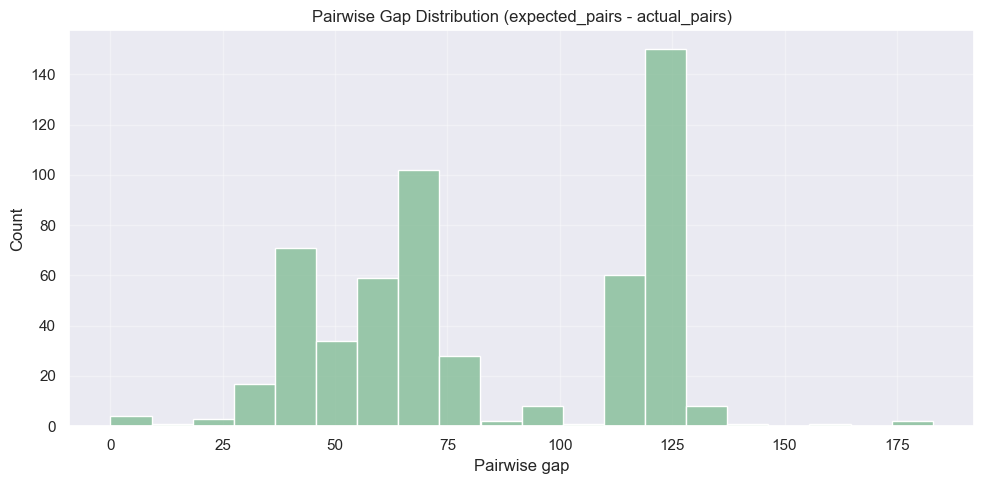

In [91]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.histplot(pairwise_completeness['pairwise_gap'], bins=20, kde=False, ax=ax)
ax.set_title('Pairwise Gap Distribution (expected_pairs - actual_pairs)')
ax.set_xlabel('Pairwise gap')
plt.tight_layout()
plt.show()

## 8. `model_win_rates` Analysis

In [92]:
win_rate_summary = pd.DataFrame([
    {'metric': 'rows', 'value': len(win_rates_df)},
    {'metric': 'rows_with_non_null_win_rate', 'value': win_rates_df['win_rate'].notna().sum()},
    {'metric': 'models', 'value': win_rates_df['model_id'].nunique() if 'model_id' in win_rates_df else np.nan},
    {'metric': 'use_cases', 'value': win_rates_df['use_case'].nunique() if 'use_case' in win_rates_df else np.nan},
    {'metric': 'complexity_slices', 'value': win_rates_df['complexity'].nunique() if 'complexity' in win_rates_df else np.nan},
])
win_rate_summary

,metric,value
0,rows,176
1,rows_with_non_null_win_rate,171
2,models,21
3,use_cases,3
4,complexity_slices,4


In [93]:
eligible_win_rates = win_rates_df[win_rates_df['win_rate'].notna()].copy()
leaderboard = eligible_win_rates.sort_values(['use_case', 'complexity', 'win_rate', 'confidence', 'decisive_matches'], ascending=[True, True, False, False, False])
leaderboard.head(30)

,model_id,use_case,complexity,win_rate,total_matches,wins,losses,ties,judge_count,last_updated,total_participations,decisive_matches,tie_rate,confidence
57,gemini-3-1-pro,code-generation,all,0.8318,337,277,56,4,3,2026-04-16 14:34:00.259278+00:00,337,333,0.0119,1.0
23,gemini-2-5-pro,code-generation,all,0.7123,293,208,84,1,3,2026-04-16 14:34:00.259278+00:00,293,292,0.0034,1.0
60,gemini-2-5-flash,code-generation,all,0.6996,274,191,82,1,3,2026-04-16 14:34:00.259278+00:00,274,273,0.0036,1.0
43,gemini-2-0-flash,code-generation,all,0.6609,349,228,117,4,3,2026-04-16 14:34:00.259278+00:00,349,345,0.0115,1.0
35,devstral-2,code-generation,all,0.5410,186,99,84,3,3,2026-04-16 14:34:00.259278+00:00,186,183,0.0161,1.0
21,llama4-maverick,code-generation,all,0.4568,249,111,132,6,3,2026-04-16 14:34:00.259278+00:00,249,243,0.0241,1.0
39,ministral-3-8b,code-generation,all,0.4044,230,91,134,5,3,2026-04-16 14:34:00.259278+00:00,230,225,0.0217,1.0
33,magistral-small,code-generation,all,0.4018,226,90,134,2,3,2026-04-16 14:34:00.259278+00:00,226,224,0.0088,1.0
85,nova-pro,code-generation,all,0.4008,239,95,142,2,3,2026-04-16 14:34:00.259278+00:00,239,237,0.0084,1.0
115,llama3-3-70b,code-generation,all,0.3810,273,104,169,0,3,2026-04-16 14:34:00.259278+00:00,273,273,0.0000,1.0


In [94]:
top_per_slice = (
    leaderboard.groupby(['use_case', 'complexity'], dropna=False)
    .head(5)
    .loc[:, ['use_case', 'complexity', 'model_id', 'win_rate', 'confidence', 'decisive_matches', 'tie_rate']]
)
top_per_slice

,use_case,complexity,model_id,win_rate,confidence,decisive_matches,tie_rate
57,code-generation,all,gemini-3-1-pro,0.8318,1.0,333,0.0119
23,code-generation,all,gemini-2-5-pro,0.7123,1.0,292,0.0034
60,code-generation,all,gemini-2-5-flash,0.6996,1.0,273,0.0036
43,code-generation,all,gemini-2-0-flash,0.6609,1.0,345,0.0115
35,code-generation,all,devstral-2,0.5410,1.0,183,0.0161
56,code-generation,high,gemini-3-1-pro,0.9286,1.0,154,0.0191
59,code-generation,high,gemini-2-5-flash,0.8431,1.0,102,0.0097
58,code-generation,high,gemini-2-5-pro,0.7895,1.0,114,0.0087
61,code-generation,high,gemini-2-0-flash,0.6491,1.0,114,0.0256
64,code-generation,high,llama4-maverick,0.4651,1.0,86,0.0000


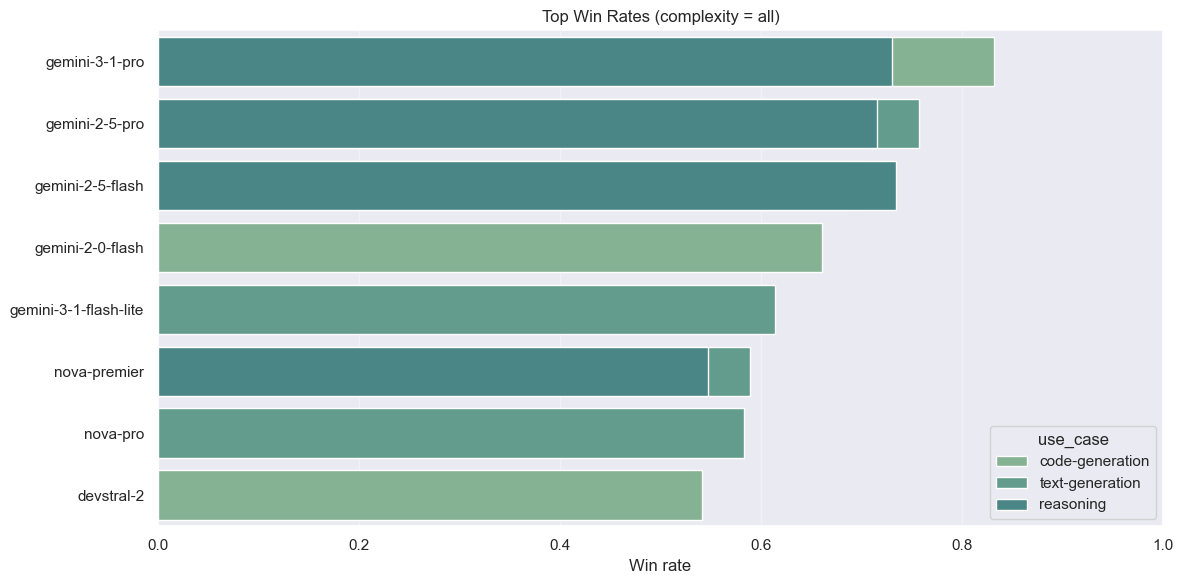

In [95]:
all_slice = eligible_win_rates[eligible_win_rates['complexity'].eq('all')].copy()
if not all_slice.empty:
    fig, ax = plt.subplots(figsize=(12, 6))
    top_all = all_slice.sort_values(['win_rate', 'confidence'], ascending=[False, False]).head(15)
    sns.barplot(data=top_all, y='model_id', x='win_rate', hue='use_case', dodge=False, ax=ax)
    ax.set_title('Top Win Rates (complexity = all)')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Win rate')
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

## 9. `routing_log` Analysis

In [96]:
routing_summary = pd.DataFrame([
    {'metric': 'rows', 'value': len(routing_df)},
    {'metric': 'unique_request_ids', 'value': routing_df['request_id'].nunique() if 'request_id' in routing_df else np.nan},
    {'metric': 'recommended_models', 'value': routing_df['recommended_model'].nunique() if 'recommended_model' in routing_df else np.nan},
    {'metric': 'data_sources', 'value': routing_df['data_source'].nunique() if 'data_source' in routing_df else np.nan},
])
routing_summary

,metric,value
0,rows,21
1,unique_request_ids,21
2,recommended_models,3
3,data_sources,1


In [97]:
if not routing_df.empty:
    display(routing_df['data_source'].value_counts(dropna=False).rename_axis('data_source').reset_index(name='rows'))
    display(routing_df['recommended_model'].value_counts(dropna=False).head(20).rename_axis('recommended_model').reset_index(name='rows'))
    display(routing_df['use_case'].value_counts(dropna=False).rename_axis('use_case').reset_index(name='rows'))

,data_source,rows
0,knn,21


,recommended_model,rows
0,gemini-2-0-flash,11
1,nova-pro,8
2,gemini-2-5-flash,2


,use_case,rows
0,code-generation,17
1,text-generation,3
2,reasoning,1


## 10. Cross-Table Integrity Checks

In [98]:
benchmark_prompt_hashes = set(benchmark_df['prompt_hash'].dropna().astype(str))
embedding_prompt_hashes = set(embeddings_df['prompt_hash'].dropna().astype(str)) if 'prompt_hash' in embeddings_df else set()
pairwise_prompt_hashes = set(pairwise_df['prompt_hash'].dropna().astype(str)) if 'prompt_hash' in pairwise_df else set()
routing_prompt_hashes = set(routing_df['prompt_hash'].dropna().astype(str)) if 'prompt_hash' in routing_df else set()
prompt_log_hashes = set(prompt_logs_df['prompt_hash'].dropna().astype(str)) if 'prompt_hash' in prompt_logs_df.columns else set()

integrity = pd.DataFrame([
    {'check': 'benchmark hashes missing in embeddings', 'count': len(benchmark_prompt_hashes - embedding_prompt_hashes)},
    {'check': 'benchmark hashes missing in pairwise', 'count': len(benchmark_prompt_hashes - pairwise_prompt_hashes)},
    {'check': 'pairwise hashes missing in benchmark', 'count': len(pairwise_prompt_hashes - benchmark_prompt_hashes)},
    {'check': 'routing hashes missing in benchmark', 'count': len(routing_prompt_hashes - benchmark_prompt_hashes)},
    {'check': 'prompt_log hashes missing in benchmark', 'count': len(prompt_log_hashes - benchmark_prompt_hashes) if prompt_log_hashes else np.nan},
])
integrity

,check,count
0,benchmark hashes missing in embeddings,0.0
1,benchmark hashes missing in pairwise,1.0
2,pairwise hashes missing in benchmark,0.0
3,routing hashes missing in benchmark,7.0
4,prompt_log hashes missing in benchmark,NaN


In [99]:
benchmark_prompt_counts = benchmark_df.groupby('prompt_hash', dropna=False).agg(
    benchmark_rows=('id', 'count'),
    benchmark_models=('model_id', 'nunique')
).reset_index()

embedding_counts = embeddings_df.groupby('prompt_hash', dropna=False).size().rename('embedding_rows').reset_index() if not embeddings_df.empty else pd.DataFrame(columns=['prompt_hash', 'embedding_rows'])
pairwise_counts = pairwise_df.groupby('prompt_hash', dropna=False).size().rename('pairwise_rows').reset_index() if not pairwise_df.empty else pd.DataFrame(columns=['prompt_hash', 'pairwise_rows'])
routing_counts = routing_df.groupby('prompt_hash', dropna=False).size().rename('routing_rows').reset_index() if not routing_df.empty and 'prompt_hash' in routing_df.columns else pd.DataFrame(columns=['prompt_hash', 'routing_rows'])

pipeline_join = benchmark_prompt_counts.merge(embedding_counts, on='prompt_hash', how='left') \
    .merge(pairwise_counts, on='prompt_hash', how='left') \
    .merge(routing_counts, on='prompt_hash', how='left')

pipeline_join = pipeline_join.fillna({'embedding_rows': 0, 'pairwise_rows': 0, 'routing_rows': 0})
pipeline_join.sort_values(['benchmark_models', 'pairwise_rows'], ascending=[False, False]).head(25)

,prompt_hash,benchmark_rows,benchmark_models,embedding_rows,pairwise_rows,routing_rows
367,a72fdf34bb5223620de200b8733fc58f,29,20,1,10.0,0.0
323,9685c092496e3b02f5118b21ab13978c,29,20,1,7.0,0.0
117,31cb01883a164281a5347e9afb7947e3,28,19,1,9.0,0.0
102,29f41d47604518868a435e82d80fd65e,27,18,1,10.0,0.0
263,7f34e02e9f6159e0d8eba37273b48040,17,17,1,20.0,0.0
274,83b5ae819fd208aa90795582fb082f20,17,17,1,20.0,0.0
348,9f30e91683c08886ed1e8d5db2e6e4fd,17,17,1,20.0,0.0
465,dafa4b76caaab2b5240318404342c79e,34,17,1,20.0,0.0
62,1c50899d1b0587c809f16c169dbe6ddf,17,17,1,19.0,0.0
84,23c1c273f3b2e80482278691c30bf734,17,17,1,19.0,0.0


## 11. Recommender-Focused Views

In [100]:
ACTIVE_MODEL_GROUPS = {
    'text-generation': [
        'llama4-scout', 'llama4-maverick', 'llama3-3-70b', 'llama3-2-90b', 'llama3-1-70b',
        'nova-lite', 'nova-pro', 'nova-premier', 'mistral-large', 'mistral-small', 'pixtral-large-2'
    ],
    'code-generation': [
        'devstral-2', 'llama4-maverick', 'llama3-3-70b', 'nova-pro', 'nova-premier',
        'pixtral-large-2', 'mistral-large', 'magistral-small', 'deepseek-r1', 'ministral-3-8b'
    ],
    'reasoning': [
        'deepseek-r1', 'magistral-small', 'nova-premier', 'nova-lite',
        'llama4-maverick', 'pixtral-large-2', 'mistral-large', 'nova-pro'
    ],
}

MODEL_PROVIDER_MAP = {
    'llama4-scout': 'Meta',
    'llama4-maverick': 'Meta',
    'llama3-3-70b': 'Meta',
    'llama3-2-90b': 'Meta',
    'llama3-1-70b': 'Meta',
    'nova-lite': 'Amazon',
    'nova-pro': 'Amazon',
    'nova-premier': 'Amazon',
    'devstral-2': 'Mistral AI',
    'ministral-3-8b': 'Mistral AI',
    'magistral-small': 'Mistral AI',
    'pixtral-large-2': 'Mistral AI',
    'mistral-large': 'Mistral AI',
    'mistral-small': 'Mistral AI',
    'deepseek-r1': 'DeepSeek',
}

SCORE_WEIGHTS = {
    'code-generation': {'win_rate': 0.40, 'syntax_rate': 0.20, 'cost': 0.25, 'latency': 0.10, 'confidence': 0.05},
    'reasoning': {'win_rate': 0.50, 'correctness': 0.20, 'cost': 0.20, 'latency': 0.05, 'confidence': 0.05},
    'text-generation': {'win_rate': 0.45, 'cost': 0.25, 'latency': 0.20, 'confidence': 0.10},
}

active_models_df = pd.DataFrame([
    {
        'use_case': use_case,
        'model_id': model_id,
        'provider': MODEL_PROVIDER_MAP.get(model_id, 'Unknown')
    }
    for use_case, model_ids in ACTIVE_MODEL_GROUPS.items()
    for model_id in model_ids
]).sort_values(['use_case', 'provider', 'model_id']).reset_index(drop=True)

active_models_df

,use_case,model_id,provider
0,code-generation,nova-premier,Amazon
1,code-generation,nova-pro,Amazon
2,code-generation,deepseek-r1,DeepSeek
3,code-generation,llama3-3-70b,Meta
4,code-generation,llama4-maverick,Meta
5,code-generation,devstral-2,Mistral AI
6,code-generation,magistral-small,Mistral AI
7,code-generation,ministral-3-8b,Mistral AI
8,code-generation,mistral-large,Mistral AI
9,code-generation,pixtral-large-2,Mistral AI


In [101]:
active_group_summary = (
    active_models_df.groupby(['use_case', 'provider'], dropna=False)
    .agg(model_count=('model_id', 'count'), models=('model_id', lambda s: ', '.join(sorted(s))))
    .reset_index()
)
active_group_summary

,use_case,provider,model_count,models
0,code-generation,Amazon,2,"nova-premier, nova-pro"
1,code-generation,DeepSeek,1,deepseek-r1
2,code-generation,Meta,2,"llama3-3-70b, llama4-maverick"
3,code-generation,Mistral AI,5,"devstral-2, magistral-small, ministral-3-8b, m..."
4,reasoning,Amazon,3,"nova-lite, nova-premier, nova-pro"
5,reasoning,DeepSeek,1,deepseek-r1
6,reasoning,Meta,1,llama4-maverick
7,reasoning,Mistral AI,3,"magistral-small, mistral-large, pixtral-large-2"
8,text-generation,Amazon,3,"nova-lite, nova-premier, nova-pro"
9,text-generation,Meta,5,"llama3-1-70b, llama3-2-90b, llama3-3-70b, llam..."


In [102]:
active_benchmark_exposure = active_models_df.merge(
    benchmark_df.groupby(['use_case', 'model_id'], dropna=False)
    .agg(
        benchmark_rows=('id', 'count'),
        prompt_hashes=('prompt_hash', 'nunique'),
        median_cost=('cost', 'median'),
        median_latency_ms=('latency_ms', 'median'),
        mean_primary_accuracy=('primary_accuracy', 'mean')
    )
    .reset_index(),
    on=['use_case', 'model_id'],
    how='left'
)

active_benchmark_exposure = active_benchmark_exposure.sort_values(['use_case', 'benchmark_rows', 'model_id'], ascending=[True, False, True])
active_benchmark_exposure

,use_case,model_id,provider,benchmark_rows,prompt_hashes,median_cost,median_latency_ms,mean_primary_accuracy
3,code-generation,llama3-3-70b,Meta,166,166,0.000513,6109.0,89.352410
4,code-generation,llama4-maverick,Meta,166,166,0.000679,5926.5,91.768072
8,code-generation,mistral-large,Mistral AI,166,166,0.004888,12949.5,86.039157
0,code-generation,nova-premier,Amazon,166,166,0.010505,14966.5,90.837349
1,code-generation,nova-pro,Amazon,166,166,0.002332,8181.0,89.942771
9,code-generation,pixtral-large-2,Mistral AI,166,166,0.005041,13054.5,89.000000
5,code-generation,devstral-2,Mistral AI,162,162,0.002770,19686.0,88.935185
7,code-generation,ministral-3-8b,Mistral AI,162,162,0.000308,8203.0,85.114198
6,code-generation,magistral-small,Mistral AI,158,158,0.001208,19290.5,88.500000
2,code-generation,deepseek-r1,DeepSeek,31,31,0.006275,9632.0,72.903226


In [103]:
active_win_rates = active_models_df.merge(
    win_rates_df[['model_id', 'use_case', 'complexity', 'win_rate', 'confidence', 'decisive_matches', 'total_matches', 'tie_rate']],
    on=['model_id', 'use_case'],
    how='left'
)

active_win_rates = active_win_rates.sort_values(['use_case', 'complexity', 'win_rate', 'confidence'], ascending=[True, True, False, False])
active_win_rates

,use_case,model_id,provider,complexity,win_rate,confidence,decisive_matches,total_matches,tie_rate
21,code-generation,devstral-2,Mistral AI,all,0.5410,1.0,183,186,0.0161
17,code-generation,llama4-maverick,Meta,all,0.4568,1.0,243,249,0.0241
29,code-generation,ministral-3-8b,Mistral AI,all,0.4044,1.0,225,230,0.0217
25,code-generation,magistral-small,Mistral AI,all,0.4018,1.0,224,226,0.0088
5,code-generation,nova-pro,Amazon,all,0.4008,1.0,237,239,0.0084
...,...,...,...,...,...,...,...,...,...
97,text-generation,llama4-maverick,Meta,mid,0.3659,1.0,82,82,0.0000
91,text-generation,llama3-2-90b,Meta,mid,0.2875,1.0,80,83,0.0361
86,text-generation,llama3-1-70b,Meta,mid,0.2632,1.0,76,76,0.0000
108,text-generation,mistral-small,Mistral AI,mid,0.2405,1.0,79,80,0.0125


In [104]:
active_all_win_rates = (
    active_win_rates[active_win_rates['complexity'].eq('all')]
    .sort_values(['use_case', 'win_rate', 'confidence'], ascending=[True, False, False])
    .loc[:, ['use_case', 'provider', 'model_id', 'win_rate', 'confidence', 'decisive_matches', 'total_matches', 'tie_rate']]
)
active_all_win_rates

,use_case,provider,model_id,win_rate,confidence,decisive_matches,total_matches,tie_rate
21,code-generation,Mistral AI,devstral-2,0.5410,1.0,183,186,0.0161
17,code-generation,Meta,llama4-maverick,0.4568,1.0,243,249,0.0241
29,code-generation,Mistral AI,ministral-3-8b,0.4044,1.0,225,230,0.0217
25,code-generation,Mistral AI,magistral-small,0.4018,1.0,224,226,0.0088
5,code-generation,Amazon,nova-pro,0.4008,1.0,237,239,0.0084
13,code-generation,Meta,llama3-3-70b,0.3810,1.0,273,273,0.0000
1,code-generation,Amazon,nova-premier,0.3615,1.0,260,263,0.0114
37,code-generation,Mistral AI,pixtral-large-2,0.3096,1.0,239,240,0.0042
33,code-generation,Mistral AI,mistral-large,0.1449,1.0,214,216,0.0093
9,code-generation,DeepSeek,deepseek-r1,0.1154,1.0,52,52,0.0000


In [105]:
recommender_candidate_view = active_models_df.merge(
    benchmark_df.groupby(['use_case', 'model_id'], dropna=False)
    .agg(
        benchmark_rows=('id', 'count'),
        benchmark_prompts=('prompt_hash', 'nunique'),
        median_cost=('cost', 'median'),
        median_latency_ms=('latency_ms', 'median'),
        syntax_rate=('syntax_pass', lambda s: pd.Series(s).dropna().astype(bool).mean() if pd.Series(s).dropna().shape[0] else np.nan),
        correctness_rate=('is_correct', lambda s: pd.Series(s).dropna().astype(bool).mean() if pd.Series(s).dropna().shape[0] else np.nan)
    )
    .reset_index(),
    on=['use_case', 'model_id'],
    how='left'
).merge(
    win_rates_df[win_rates_df['complexity'].eq('all')][['model_id', 'use_case', 'win_rate', 'confidence', 'decisive_matches', 'tie_rate']],
    on=['model_id', 'use_case'],
    how='left'
)

recommender_candidate_view = recommender_candidate_view.sort_values(['use_case', 'win_rate', 'confidence', 'benchmark_rows'], ascending=[True, False, False, False])
recommender_candidate_view

,use_case,model_id,provider,benchmark_rows,benchmark_prompts,median_cost,median_latency_ms,syntax_rate,correctness_rate,win_rate,confidence,decisive_matches,tie_rate
5,code-generation,devstral-2,Mistral AI,162,162,0.002770,19686.0,<NA>,<NA>,0.5410,1.0,183,0.0161
4,code-generation,llama4-maverick,Meta,166,166,0.000679,5926.5,<NA>,<NA>,0.4568,1.0,243,0.0241
7,code-generation,ministral-3-8b,Mistral AI,162,162,0.000308,8203.0,<NA>,<NA>,0.4044,1.0,225,0.0217
6,code-generation,magistral-small,Mistral AI,158,158,0.001208,19290.5,<NA>,<NA>,0.4018,1.0,224,0.0088
1,code-generation,nova-pro,Amazon,166,166,0.002332,8181.0,<NA>,<NA>,0.4008,1.0,237,0.0084
3,code-generation,llama3-3-70b,Meta,166,166,0.000513,6109.0,<NA>,<NA>,0.3810,1.0,273,0.0000
0,code-generation,nova-premier,Amazon,166,166,0.010505,14966.5,<NA>,<NA>,0.3615,1.0,260,0.0114
9,code-generation,pixtral-large-2,Mistral AI,166,166,0.005041,13054.5,<NA>,<NA>,0.3096,1.0,239,0.0042
8,code-generation,mistral-large,Mistral AI,166,166,0.004888,12949.5,<NA>,<NA>,0.1449,1.0,214,0.0093
2,code-generation,deepseek-r1,DeepSeek,31,31,0.006275,9632.0,<NA>,<NA>,0.1154,1.0,52,0.0000


In [106]:
for use_case in ACTIVE_MODEL_GROUPS:
    print('\n' + '=' * 100)
    print(f'Recommender Slice: {use_case}')
    print(f'Weights used: {SCORE_WEIGHTS.get(use_case)}')
    display(
        recommender_candidate_view[recommender_candidate_view['use_case'].eq(use_case)]
        .loc[:, [
            'provider', 'model_id', 'benchmark_rows', 'benchmark_prompts', 'win_rate', 'confidence',
            'decisive_matches', 'tie_rate', 'median_cost', 'median_latency_ms', 'syntax_rate', 'correctness_rate'
        ]]
        .reset_index(drop=True)
    )


Recommender Slice: text-generation
Weights used: {'win_rate': 0.45, 'cost': 0.25, 'latency': 0.2, 'confidence': 0.1}


,provider,model_id,benchmark_rows,benchmark_prompts,win_rate,confidence,decisive_matches,tie_rate,median_cost,median_latency_ms,syntax_rate,correctness_rate
0,Amazon,nova-premier,264,238,0.5893,1.0,336,0.0118,0.005064,28697.5,<NA>,<NA>
1,Amazon,nova-pro,266,240,0.5826,1.0,321,0.0123,0.001656,25466.5,<NA>,<NA>
2,Amazon,nova-lite,266,240,0.5117,1.0,299,0.0197,0.000091,22482.5,<NA>,<NA>
3,Mistral AI,pixtral-large-2,266,240,0.5000,1.0,212,0.0000,0.003761,28511.0,<NA>,<NA>
4,Meta,llama4-maverick,263,237,0.3913,1.0,276,0.0000,0.000363,21500.0,<NA>,<NA>
5,Meta,llama3-2-90b,265,239,0.3792,1.0,269,0.0147,0.000339,28569.0,<NA>,<NA>
6,Meta,llama3-3-70b,265,239,0.3642,1.0,313,0.0063,0.000333,22240.0,<NA>,<NA>
7,Meta,llama4-scout,264,238,0.3623,1.0,265,0.0000,0.000316,21685.0,<NA>,<NA>
8,Meta,llama3-1-70b,264,238,0.3392,1.0,227,0.0044,0.000321,36333.5,<NA>,<NA>
9,Mistral AI,mistral-large,264,238,0.3172,1.0,268,0.0074,0.004454,28093.0,<NA>,<NA>



Recommender Slice: code-generation
Weights used: {'win_rate': 0.4, 'syntax_rate': 0.2, 'cost': 0.25, 'latency': 0.1, 'confidence': 0.05}


,provider,model_id,benchmark_rows,benchmark_prompts,win_rate,confidence,decisive_matches,tie_rate,median_cost,median_latency_ms,syntax_rate,correctness_rate
0,Mistral AI,devstral-2,162,162,0.5410,1.0,183,0.0161,0.002770,19686.0,<NA>,<NA>
1,Meta,llama4-maverick,166,166,0.4568,1.0,243,0.0241,0.000679,5926.5,<NA>,<NA>
2,Mistral AI,ministral-3-8b,162,162,0.4044,1.0,225,0.0217,0.000308,8203.0,<NA>,<NA>
3,Mistral AI,magistral-small,158,158,0.4018,1.0,224,0.0088,0.001208,19290.5,<NA>,<NA>
4,Amazon,nova-pro,166,166,0.4008,1.0,237,0.0084,0.002332,8181.0,<NA>,<NA>
5,Meta,llama3-3-70b,166,166,0.3810,1.0,273,0.0000,0.000513,6109.0,<NA>,<NA>
6,Amazon,nova-premier,166,166,0.3615,1.0,260,0.0114,0.010505,14966.5,<NA>,<NA>
7,Mistral AI,pixtral-large-2,166,166,0.3096,1.0,239,0.0042,0.005041,13054.5,<NA>,<NA>
8,Mistral AI,mistral-large,166,166,0.1449,1.0,214,0.0093,0.004888,12949.5,<NA>,<NA>
9,DeepSeek,deepseek-r1,31,31,0.1154,1.0,52,0.0000,0.006275,9632.0,<NA>,<NA>



Recommender Slice: reasoning
Weights used: {'win_rate': 0.5, 'correctness': 0.2, 'cost': 0.2, 'latency': 0.05, 'confidence': 0.05}


,provider,model_id,benchmark_rows,benchmark_prompts,win_rate,confidence,decisive_matches,tie_rate,median_cost,median_latency_ms,syntax_rate,correctness_rate
0,Amazon,nova-premier,188,149,0.5474,1.0,285,0.0104,0.008164,9268.5,<NA>,<NA>
1,Amazon,nova-pro,188,149,0.5067,1.0,225,0.0044,0.001883,5356.5,<NA>,<NA>
2,Mistral AI,magistral-small,188,149,0.4611,1.0,321,0.0093,0.001182,14951.5,<NA>,<NA>
3,Amazon,nova-lite,188,149,0.4571,1.0,245,0.0000,0.000146,4306.5,<NA>,<NA>
4,Mistral AI,pixtral-large-2,188,149,0.4350,1.0,246,0.0120,0.003414,8784.0,<NA>,<NA>
5,Meta,llama4-maverick,188,149,0.3485,1.0,241,0.0000,0.000489,4380.0,<NA>,<NA>
6,DeepSeek,deepseek-r1,55,37,0.2667,1.0,30,0.0000,0.004649,8342.0,<NA>,<NA>
7,Mistral AI,mistral-large,188,149,0.1864,1.0,220,0.0000,0.003836,9612.0,<NA>,<NA>


In [107]:
active_slice_matrix = (
    active_win_rates.pivot_table(
        index=['use_case', 'model_id'],
        columns='complexity',
        values='win_rate',
        aggfunc='first'
    )
    .reset_index()
    .sort_values(['use_case', 'all', 'high', 'mid', 'low'], ascending=[True, False, False, False, False])
)
active_slice_matrix

complexity,use_case,model_id,all,high,low,mid
1,code-generation,devstral-2,0.5410,0.4615,0.5357,0.6000
3,code-generation,llama4-maverick,0.4568,0.4651,0.4462,0.4565
5,code-generation,ministral-3-8b,0.4044,0.2667,0.4516,0.4886
4,code-generation,magistral-small,0.4018,0.2737,0.5789,0.4615
8,code-generation,nova-pro,0.4008,0.3750,0.3939,0.4242
2,code-generation,llama3-3-70b,0.3810,0.3365,0.3284,0.4608
7,code-generation,nova-premier,0.3615,0.2747,0.4133,0.4043
9,code-generation,pixtral-large-2,0.3096,0.2211,0.3390,0.3882
6,code-generation,mistral-large,0.1449,0.1579,0.1613,0.1184
0,code-generation,deepseek-r1,0.1154,0.1000,0.1667,0.0000


## 12. Recommended Follow-Up Checks

Use the tables above to answer operational questions such as:
- Which prompt hashes have benchmark rows but no embeddings?
- Which prompt hashes have 3 benchmarked models but fewer than 3 pairwise rows?
- Which models show strong `win_rate` but low `confidence` due to limited decisive matches?
- Which data sources dominate routing decisions in `routing_log`?
- How many legacy benchmark rows still lack the newer prompt-hash or pairwise-derived fields?
